In [2]:
import numpy as np
from numpy import pi
import matplotlib.pyplot as plt
%matplotlib inline

Matplotlib is building the font cache; this may take a moment.


# Вариант 6

### Задание

1. Ознакомиться с теоретической частью.

2. Для заданных дискретных сигналов ( ) и y( ) (либо специально подобранных музыкальных файлов) выполнить следующие задания (в соответствии с заданным вариантом, выданным преподавателем):

    <!-- - реализовать операцию свертки двух сигналов; -->
    
    - реализовать операцию корреляции двух сигналов;
    
    - для сигналов x( ) и y( ), а также результата выполнения операции свертки выполнить прямое и обратное преобразование Фурье;
    
    - построить графики амплитудного и фазового спектра сигналов;
    
    - построить графики сигналов во временной области;
    
    - экспериментально проверить корректность схем вычисления свертки и корреляции (в соответствии с рисунками 15 и 16).

3. Сравнить полученные результаты при разных значениях, оценить эффективность алгоритмов в зависимости от .

> Примечание. Прямое и обратное преобразования Фурье, вычисление операций свертки и корреляции должны быть представлены в двух вариантах – реализованные студентом самостоятельно и с использованием Open Source библиотек.

4. Оформить итоговый отчет с указанием исходных данных, результатов работы, построенных графиков, выводами о результатах работы.

#### Графики
<!-- 1.	x(t)	x(t) -->
<!-- 2.	y(t)	y(t) -->
3.	x(t)	ДПФ: амплитудный спектр
4.	x(t)	ДПФ: фазовый спектр
5.	x(t)	ОДПФ
6.	x(t)	БПФ: амплитудный спектр
7.	x(t)	БПФ: фазовый спектр
8.	x(t)	ОБПФ
9.	y(t)	ДПФ: амплитудный спектр
10.	y(t)	ДПФ: фазовый спектр
11.	y(t)	ОДПФ
12.	y(t)	БПФ: амплитудный спектр
13.	y(t)	БПФ: фазовый спектр
14.	y(t)	ОБПФ
<!-- 15.	x(t) y(t)	Свертка -->
16.	x(t) y(t)	Свертка через БПФ
17.	x(t) y(t)	Корреляция
18.	x(t) y(t)	Корреляция через БПФ
##### С использованием Open Source библиотек.	
19.	x(t)	БПФ: амплитудный спектр
20.	x(t)	БПФ: фазовый спектр
21.	y(t)	БПФ: амплитудный спектр
22.	y(t)	БПФ: фазовый спектр
<!-- 23.	x(t) y(t)	Свертка -->
<!-- 25.	x(t) y(t)	Корреляция -->

- x(t) = Орган С4

In [3]:
A_x = [1, 0.5, 0.3, 0.1]
f0_x = 262 #Hz
h_x = [1, 2, 4, 8]
phi_x = 0

- y(t) = Орган E4

In [4]:
A_y = [1, 0.4, 0.2, 0.1]
f0_y = 330 #Hz
h_y = [1, 2, 4, 8]
phi_y = 0

### Графики

In [77]:
def plot(y, x, title: str|None = None):
    plt.figure(figsize=(4, 3))
    plt.plot(x, y)
    plt.title(title)
    plt.grid(True)
    plt.show() 

In [78]:
SAMPLING_FREQ = 44100
SAMPLE_COUNT = 512

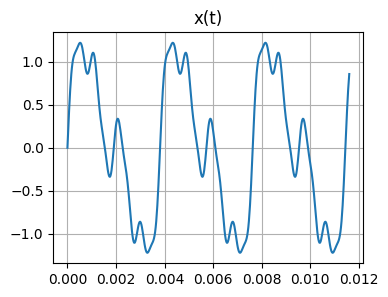

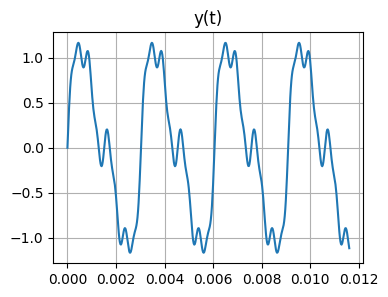

In [79]:
def s(t, A, h, f0, phi):
    assert(len(A) == len(h))
    return sum(
        A[i] * np.sin(2*pi * h[i] * f0 * t + phi)
        for i in range(0, len(A))
    )

t = np.linspace(0, SAMPLE_COUNT/SAMPLING_FREQ, SAMPLE_COUNT)

x = s(t, A_x, h_x, f0_x, phi_x)
plot(x, t, "x(t)")

y = s(t, A_y, h_y, f0_y, phi_y)
plot(y, t, "y(t)")

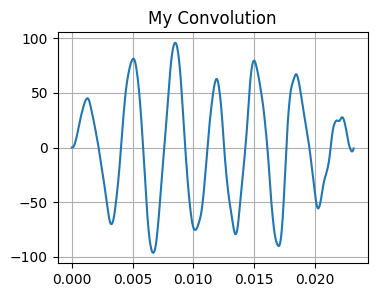

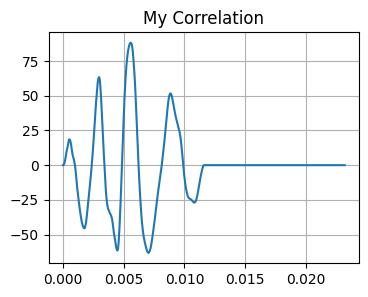

In [97]:
def convolve(x, y):
    N = len(x) + len(y) - 1
    return [sum(
        (x[m] if m < len(x) else 0) * 
        (y[n-m] if n-m < len(y) else 0)
        for m in range(0, n)
    ) for n in range(0, N)]
def correlate(x, y):
    N = len(x) + len(y) - 1
    return [sum(
        (x[m] if m < len(x) else 0) * 
        (y[n+m] if n+m < len(y) else 0)
        for m in range(0, n)
    ) for n in range(0, N)]
    
t_ = np.linspace(0, (2*SAMPLE_COUNT - 1)/SAMPLING_FREQ, (2*SAMPLE_COUNT - 1))

conv = convolve(x, y)
plot(conv, t_, "My Convolution")

corr = correlate(x, y)
plot(corr, t_, "My Correlation")

In [ ]:
def dft(x):
    

### С использованием библиотек

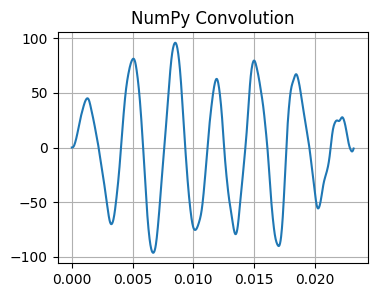

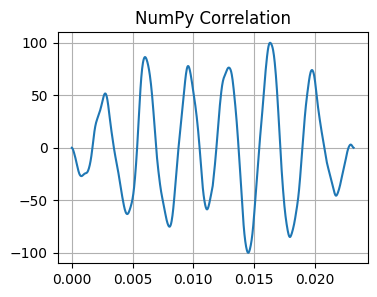

In [95]:
np_conv = np.convolve(x, y)
plot(np_conv, t_, "NumPy Convolution")

np_corr = np.correlate(x, y, "full")
plot(np_corr, t_, "NumPy Correlation")

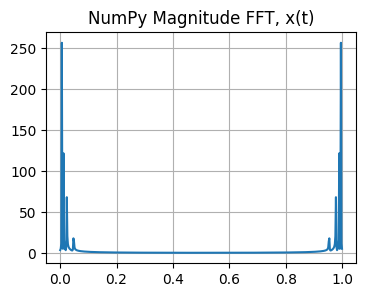

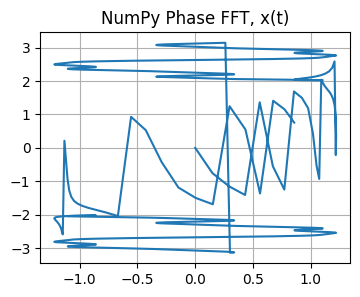

In [101]:
f = np.linspace(0, 1, SAMPLE_COUNT)
np_fft = np.fft.fft(x)
plot(np.abs(np_fft), f, "NumPy Magnitude FFT, x(t)")
plot(np.angle(np_fft), x, "NumPy Phase FFT, x(t)")

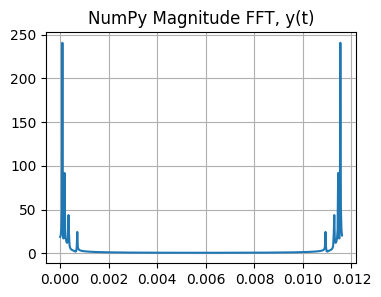

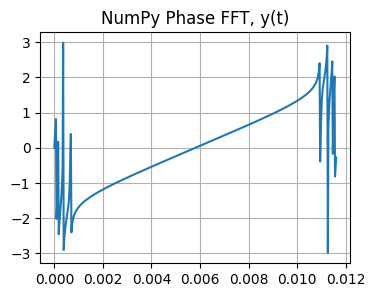

In [59]:
np_fft = np.fft.fft(y)
plot(np.abs(np_fft), t, "NumPy Magnitude FFT, y(t)")
plot(np.angle(np_fft), t, "NumPy Phase FFT, y(t)")